# 03 — Exploratory Data Analysis

**IT3051 – Fundamentals of Data Mining · Mini Project 2026**

Explore the raw Hotel Booking Demand dataset and its binary target `is_canceled` (**0 = Not Cancelled; 1 = Cancelled**). Examine distributions and cancellation associations, with particular attention to **City Hotel versus Resort Hotel**. Descriptive differences can motivate later comparison of a general model and hotel-specific models; they do not establish which will perform better.

All observations are descriptive and do not establish causation or statistical significance. No preprocessing, permanent feature engineering, or model development is performed. The raw CSV and `df` remain unchanged. Existing data-quality issues and repeated records remain in every full-data calculation; see `02_data_quality_audit.ipynb` for their detailed audit.

## 2 — Load raw data and analysis conventions

Use the same root/notebooks path strategy as earlier notebooks. Rates use all records in the displayed group; a missing or unexpected target causes a clear error rather than an ambiguous rate. A temporary grouping can include a missing category, which remains visible in tables.

Every rate table includes booking counts. Groups with fewer than 100 records are flagged for descriptive caution only; 100 is a display convention, not a statistical threshold. No records are excluded because a group is small. Numerical summaries omit missing measurements and report their count. Plotting helpers save PNGs only under `reports/figures/` and use a shared 0–100% cancellation-rate scale.

In [1]:
from pathlib import Path
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
project_root = next((candidate for candidate in (cwd, cwd.parent)
    if (candidate / "requirements.txt").is_file()
    and (candidate / "notebooks").is_dir()
    and (candidate / "data" / "raw").is_dir()), None)
if project_root is None:
    raise FileNotFoundError("Run from the repository root or notebooks directory.")
data_path = project_root / "data" / "raw" / "hotel_bookings.csv"
if not data_path.is_file():
    raise FileNotFoundError("Place hotel_bookings.csv inside data/raw/.")
raw_hash_before = hashlib.sha256(data_path.read_bytes()).hexdigest()
df = pd.read_csv(data_path)
if not {"hotel", "is_canceled"}.issubset(df.columns):
    raise ValueError("The dataset must contain hotel and is_canceled.")
if not df["is_canceled"].isin([0, 1]).all():
    raise ValueError("Missing or unexpected target values require review before calculating rates.")
if not df["hotel"].isin(["City Hotel", "Resort Hotel"]).all():
    raise ValueError("Missing or unexpected hotel categories require review.")
figure_dir = project_root / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_names = []
hotel_order = ["City Hotel", "Resort Hotel"]
colours = ["#2563A6", "#CF7A2C"]
class_labels = {0: "Not Cancelled", 1: "Cancelled"}
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlepad": 12})
print(f"Dataset: {data_path.relative_to(project_root).as_posix()}")
print(f"Shape: {df.shape}; pandas: {pd.__version__}")

def rates(group, by_hotel=False):
    view = pd.DataFrame({"Group": group, "hotel": df["hotel"], "Target": df["is_canceled"]})
    keys = ["hotel", "Group"] if by_hotel else ["Group"]
    table = view.groupby(keys, observed=True, dropna=False, sort=True)["Target"].agg(Bookings="size", Cancelled="sum")
    table["Not Cancelled"] = table["Bookings"] - table["Cancelled"]
    table["Cancellation rate (%)"] = 100 * table["Cancelled"] / table["Bookings"]
    table["Non-cancellation rate (%)"] = 100 - table["Cancellation rate (%)"]
    table["Small group (n < 100)"] = table["Bookings"] < 100
    return table

def show_rates(table):
    display(table.round(2))

def numerical_summary(values):
    return values.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("Value")

def outcome_summary(values):
    return values.groupby(df["is_canceled"]).agg(["count", "mean", "median", "min", "max"]).rename(index=class_labels)

def finish(fig, filename):
    fig.tight_layout()
    fig.savefig(figure_dir / filename, dpi=150, bbox_inches="tight")
    figure_names.append(filename)
    plt.show()
    plt.close(fig)

def rate_plot(table, title, filename):
    fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(table))))
    ax.barh([str(label) for label in table.index], table["Cancellation rate (%)"], color=colours[0])
    for i, (_, row) in enumerate(table.iterrows()):
        x = row["Cancellation rate (%)"]
        ax.text(min(x + 1, 98), i, f"{x:.1f}% · n={int(row['Bookings']):,}",
                va="center", ha="right" if x > 70 else "left", fontsize=9)
    ax.set(xlim=(0, 100), xlabel="Observed cancellation rate (%)", ylabel=table.index.name or "Group", title=title)
    ax.invert_yaxis()
    finish(fig, filename)

def hotel_rate_plot(table, title, xlabel, filename, order=None):
    comparison = table["Cancellation rate (%)"].unstack("hotel").reindex(columns=hotel_order)
    if order is not None:
        comparison = comparison.reindex(order)
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(comparison))
    for i, hotel in enumerate(hotel_order):
        ax.plot(x, comparison[hotel], marker="o", label=hotel, color=colours[i])
    ax.set(xticks=x, xticklabels=[str(v) for v in comparison.index], ylim=(0, 100),
           ylabel="Observed cancellation rate (%)", xlabel=xlabel, title=title)
    ax.tick_params(axis="x", labelrotation=30)
    ax.legend()
    finish(fig, filename)

def evidence(table, group):
    row = table.loc[group]
    return f"{group}: {row['Cancellation rate (%)']:.2f}% (n={int(row['Bookings']):,})"

findings = {}

Dataset: data/raw/hotel_bookings.csv
Shape: (119390, 32); pandas: 3.0.3


## 3 — Target distribution

Count both outcomes and their shares of all bookings. The chart shows counts; no class balancing treatment is selected.

,Outcome,Bookings,Percentage
0,Not Cancelled,75166,62.96
1,Cancelled,44224,37.04


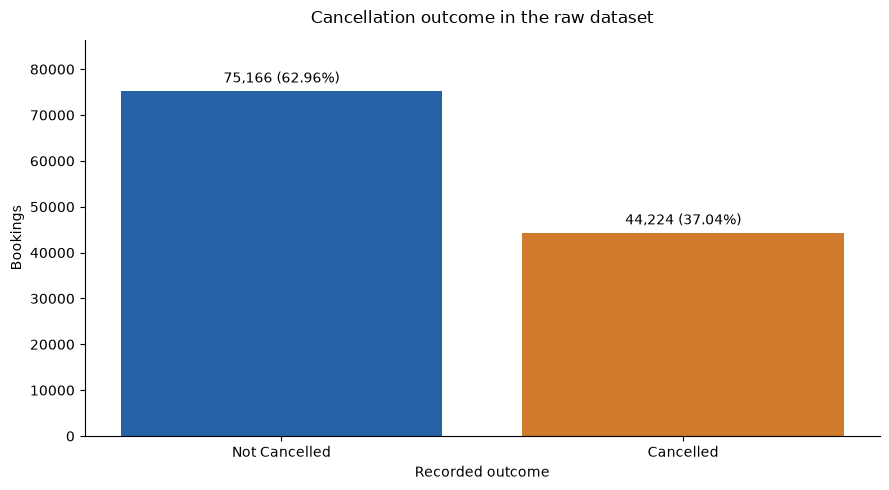

Not Cancelled: 75,166 (62.96%); Cancelled: 44,224 (37.04%). The class distribution is not perfectly balanced. No resampling decision is made.

In [2]:
target_counts = df["is_canceled"].value_counts().reindex([0, 1])
target_table = pd.DataFrame({"Outcome": [class_labels[v] for v in target_counts.index],
    "Bookings": target_counts.to_numpy(), "Percentage": 100 * target_counts.to_numpy() / len(df)})
display(target_table.round(2))
fig, ax = plt.subplots()
bars = ax.bar(target_table["Outcome"], target_table["Bookings"], color=colours)
ax.bar_label(bars, labels=[f"{n:,} ({p:.2f}%)" for n, p in zip(target_table["Bookings"], target_table["Percentage"])], padding=4)
ax.set(title="Cancellation outcome in the raw dataset", xlabel="Recorded outcome", ylabel="Bookings", ylim=(0, target_counts.max() * 1.15))
finish(fig, "target_distribution.png")
overall_rate = 100 * df["is_canceled"].mean()
findings["target"] = (f"Not Cancelled: {int(target_counts.loc[0]):,} ({100-overall_rate:.2f}%); "
    f"Cancelled: {int(target_counts.loc[1]):,} ({overall_rate:.2f}%). "
    f"The class distribution is {'perfectly balanced' if target_counts.loc[0] == target_counts.loc[1] else 'not perfectly balanced'}. No resampling decision is made.")
display(Markdown(findings["target"]))

## 4 — Hotel type distribution

Compare the contribution of each hotel type to the combined dataset. Overall patterns can be influenced by this unequal composition.

,Bookings,Percentage
hotel,,
City Hotel,79330,66.45
Resort Hotel,40060,33.55


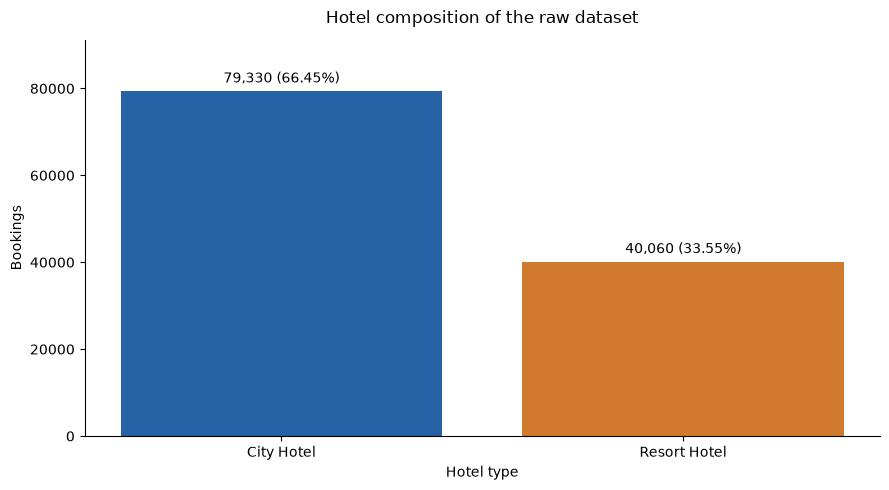

City Hotel contributes 66.45% of records; Resort Hotel contributes 33.55%.

In [3]:
hotel_counts = df["hotel"].value_counts().reindex(hotel_order)
display(pd.DataFrame({"Bookings": hotel_counts, "Percentage": 100 * hotel_counts / len(df)}).round(2))
fig, ax = plt.subplots()
bars = ax.bar(hotel_order, hotel_counts, color=colours)
ax.bar_label(bars, labels=[f"{n:,} ({100*n/len(df):.2f}%)" for n in hotel_counts], padding=4)
ax.set(title="Hotel composition of the raw dataset", ylabel="Bookings", xlabel="Hotel type", ylim=(0, hotel_counts.max() * 1.15))
finish(fig, "hotel_type_distribution.png")
display(Markdown(f"City Hotel contributes {100*hotel_counts.loc['City Hotel']/len(df):.2f}% of records; Resort Hotel contributes {100*hotel_counts.loc['Resort Hotel']/len(df):.2f}%."))

## 5 — Cancellation rate by hotel type

Use within-hotel denominators so unequal hotel sizes do not obscure the comparison. Report both outcomes and rates.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
City Hotel,79330,33102,46228,41.73,58.27,False
Resort Hotel,40060,11122,28938,27.76,72.24,False


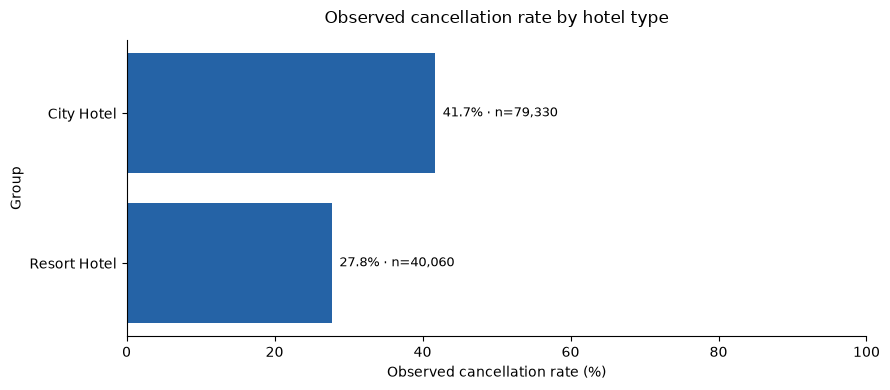

City Hotel: 41.73%; Resort Hotel: 27.76%. City minus Resort is 13.96 percentage points. This descriptive difference motivates hotel-specific investigation; it does not establish significance, causation, or model superiority.

In [4]:
hotel_rates = rates(df["hotel"]).reindex(hotel_order)
show_rates(hotel_rates)
rate_plot(hotel_rates, "Observed cancellation rate by hotel type", "cancellation_rate_by_hotel.png")
city_rate = hotel_rates.loc["City Hotel", "Cancellation rate (%)"]
resort_rate = hotel_rates.loc["Resort Hotel", "Cancellation rate (%)"]
findings["hotel_rates"] = (f"City Hotel: {city_rate:.2f}%; Resort Hotel: {resort_rate:.2f}%. "
    f"City minus Resort is {city_rate-resort_rate:.2f} percentage points. "
    "This descriptive difference motivates hotel-specific investigation; it does not establish significance, causation, or model superiority.")
display(Markdown(findings["hotel_rates"]))

## 6 — Lead time analysis

Summarise the full observed distribution and each outcome. Histogram counts use a logarithmic **y-axis** to keep sparse tails visible; lead time itself is not transformed. Fixed lead-time ranges are temporary analytical groups, not engineered model features. Their boundaries are right-inclusive (for example, 8–30 includes values above 7 through 30).

,Value
count,119390.00
mean,104.01
std,106.86
min,0.00
25%,18.00
50%,69.00
75%,160.00
95%,320.00
99%,444.00
max,737.00


,count,mean,median,min,max
is_canceled,,,,,
Not Cancelled,75166,79.98,45.0,0,737
Cancelled,44224,144.85,113.0,0,629


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,6345,430,5915,6.78,93.22,False
1–7,13401,1472,11929,10.98,89.02,False
8–30,18960,5283,13677,27.86,72.14,False
31–90,29553,11141,18412,37.70,62.30,False
91–180,26439,11821,14618,44.71,55.29,False
181–365,21544,11947,9597,55.45,44.55,False
>365,3148,2130,1018,67.66,32.34,False


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                         
City Hotel   ≤0           3109        273           2836   
             1–7          7699       1046           6653   
             8–30        12554       3880           8674   
             31–90       20797       8300          12497   
             91–180      18223       8746           9477   
             181–365     14244       8934           5310   
             >365         2704       1923            781   
Resort Hotel ≤0           3236        157           3079   
             1–7          5702        426           5276   
             8–30         6406       1403           5003   
             31–90        8756       2841           5915   
             91–180       8216       3075           5141   
             181–365      7300       3013           4287   
             >365          444        207            237   

                      Cancellation rate (%)  Non-cancellation rate (%)  \
hotel        Group                                                       
City Hotel   ≤0                        8.78                      91.22   
             1–7                      13.59                      86.41   
             8–30                     30.91                      69.09   
             31–90                    39.91                      60.09   
             91–180                   47.99                      52.01   
             181–365                  62.72                      37.28   
             >365                     71.12                      28.88   
Resort Hotel ≤0                        4.85                      95.15   
             1–7                       7.47                      92.53   
             8–30                     21.90                      78.10   
             31–90                    32.45                      67.55   
             91–180                   37.43                      62.57   
             181–365                  41.27                      58.73   
             >365                     46.62                      53.38   

                      Small group (n < 100)  
hotel        Group                           
City Hotel   ≤0                       False  
             1–7                      False  
             8–30                     False  
             31–90                    False  
             91–180                   False  
             181–365                  False  
             >365                     False  
Resort Hotel ≤0                       False  
             1–7                      False  
             8–30                     False  
             31–90                    False  
             91–180                   False  
             181–365                  False  
             >365                     False

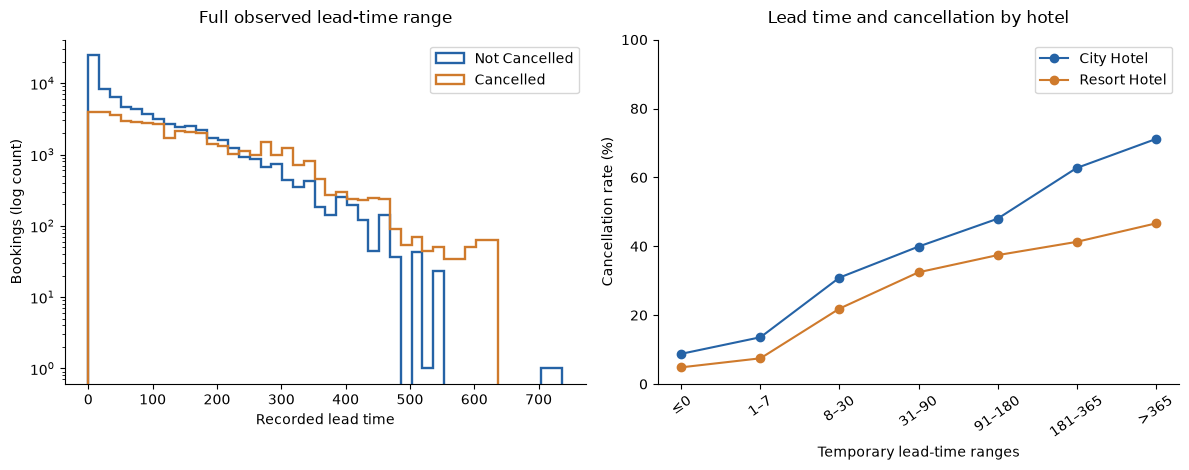

Median lead time is 113 for Cancelled and 45 for Not Cancelled records. 1–7: 10.98% (n=13,401); 181–365: 55.45% (n=21,544). These are unadjusted associations.

In [5]:
display(numerical_summary(df["lead_time"]).round(2))
lead_outcomes = outcome_summary(df["lead_time"])
display(lead_outcomes.round(2))
lead_groups = pd.cut(df["lead_time"], [-np.inf, 0, 7, 30, 90, 180, 365, np.inf],
    labels=["≤0", "1–7", "8–30", "31–90", "91–180", "181–365", ">365"])
lead_rates = rates(lead_groups)
lead_hotel_rates = rates(lead_groups, True)
show_rates(lead_rates)
show_rates(lead_hotel_rates)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for value, colour in zip([0, 1], colours):
    axes[0].hist(df.loc[df["is_canceled"] == value, "lead_time"], bins=np.linspace(df["lead_time"].min(), df["lead_time"].max(), 45),
        histtype="step", linewidth=1.7, color=colour, label=class_labels[value])
axes[0].set(yscale="log", xlabel="Recorded lead time", ylabel="Bookings (log count)", title="Full observed lead-time range")
axes[0].legend()
lead_pivot = lead_hotel_rates["Cancellation rate (%)"].unstack("hotel")
for hotel, colour in zip(hotel_order, colours):
    axes[1].plot(np.arange(len(lead_pivot)), lead_pivot[hotel], marker="o", color=colour, label=hotel)
axes[1].set(xticks=np.arange(len(lead_pivot)), xticklabels=lead_pivot.index, ylim=(0, 100),
    xlabel="Temporary lead-time ranges", ylabel="Cancellation rate (%)", title="Lead time and cancellation by hotel")
axes[1].tick_params(axis="x", labelrotation=35)
axes[1].legend()
finish(fig, "lead_time_by_cancellation.png")
findings["lead"] = (f"Median lead time is {lead_outcomes.loc['Cancelled', 'median']:g} for Cancelled and "
    f"{lead_outcomes.loc['Not Cancelled', 'median']:g} for Not Cancelled records. "
    + evidence(lead_rates, "1–7") + "; " + evidence(lead_rates, "181–365") + ". These are unadjusted associations.")
display(Markdown(findings["lead"]))

## 7 — Arrival and seasonal patterns

Order months by the calendar. Pooling years gives a descriptive month comparison, not an estimate of a causal seasonal effect. Show year-by-month coverage as a check on unequal exposure; partial years and differing booking mixes limit comparisons. No extra week-level chart is needed for this focused investigation.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
January,5929,1807,4122,30.48,69.52,False
February,8068,2696,5372,33.42,66.58,False
March,9794,3149,6645,32.15,67.85,False
April,11089,4524,6565,40.80,59.20,False
May,11791,4677,7114,39.67,60.33,False
June,10939,4535,6404,41.46,58.54,False
July,12661,4742,7919,37.45,62.55,False
August,13877,5239,8638,37.75,62.25,False
September,10508,4116,6392,39.17,60.83,False


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                           
City Hotel   January        3736       1482           2254   
             February       4965       1901           3064   
             March          6458       2386           4072   
             April          7480       3465           4015   
             May            8232       3653           4579   
             June           7894       3528           4366   
             July           8088       3306           4782   
             August         8983       3602           5381   
             September      7400       3110           4290   
             October        7605       3268           4337   
             November       4357       1661           2696   
             December       4132       1740           2392   
Resort Hotel January        2193        325           1868   
             February       3103        795           2308   
             March          3336        763           2573   
             April          3609       1059           2550   
             May            3559       1024           2535   
             June           3045       1007           2038   
             July           4573       1436           3137   
             August         4894       1637           3257   
             September      3108       1006           2102   
             October        3555        978           2577   
             November       2437        461           1976   
             December       2648        631           2017   

                        Cancellation rate (%)  Non-cancellation rate (%)  \
hotel        Group                                                         
City Hotel   January                    39.67                      60.33   
             February                   38.29                      61.71   
             March                      36.95                      63.05   
             April                      46.32                      53.68   
             May                        44.38                      55.62   
             June                       44.69                      55.31   
             July                       40.88                      59.12   
             August                     40.10                      59.90   
             September                  42.03                      57.97   
             October                    42.97                      57.03   
             November                   38.12                      61.88   
             December                   42.11                      57.89   
Resort Hotel January                    14.82                      85.18   
             February                   25.62                      74.38   
             March                      22.87                      77.13   
             April                      29.34                      70.66   
             May                        28.77                      71.23   
             June                       33.07                      66.93   
             July                       31.40                      68.60   
             August                     33.45                      66.55   
             September                  32.37                      67.63   
             October                    27.51                      72.49   
             November                   18.92                      81.08   
             December                   23.83                      76.17   

                        Small group (n < 100)  
hotel        Group                             
City Hotel   January                    False  
             February                   False  
             March                      False  
             April                      False  
             May                        False  
             June                       False  
             July                       False  
  

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
2015,21996,8142,13854,37.02,62.98,False
2016,56707,20337,36370,35.86,64.14,False
2017,40687,15745,24942,38.70,61.30,False


arrival_date_month,January,February,March,April,May,June,July,August,September,October,November,December
arrival_date_year,,,,,,,,,,,,
2015,0,0,0,0,0,0,2776,3889,5114,4957,2340,2920
2016,2248,3891,4824,5428,5478,5292,4572,5063,5394,6203,4454,3860
2017,3681,4177,4970,5661,6313,5647,5313,4925,0,0,0,0


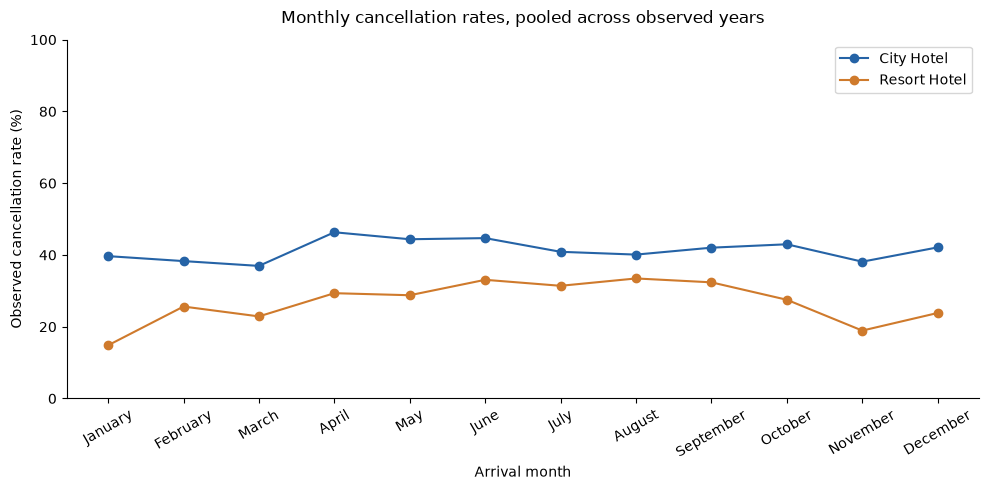

Pooled monthly extremes: June: 41.46% (n=10,939); January: 30.48% (n=5,929). Observed months per year: 2015: 6; 2016: 12; 2017: 8. Unequal month coverage and hotel composition limit a seasonal interpretation.

In [6]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_rates = rates(df["arrival_date_month"]).reindex(months)
month_hotel_rates = rates(df["arrival_date_month"], True)
show_rates(month_rates)
show_rates(month_hotel_rates.reindex(pd.MultiIndex.from_product([hotel_order, months], names=["hotel", "Group"])))
year_rates = rates(df["arrival_date_year"])
show_rates(year_rates)
coverage = pd.crosstab(df["arrival_date_year"], df["arrival_date_month"]).reindex(columns=months)
display(coverage)
hotel_rate_plot(month_hotel_rates, "Monthly cancellation rates, pooled across observed years", "Arrival month", "monthly_cancellation_by_hotel.png", months)
highest_month = month_rates["Cancellation rate (%)"].idxmax()
lowest_month = month_rates["Cancellation rate (%)"].idxmin()
findings["months"] = ("Pooled monthly extremes: " + evidence(month_rates, highest_month) + "; " + evidence(month_rates, lowest_month) +
    ". Observed months per year: " + "; ".join(f"{year}: {int((row > 0).sum())}" for year, row in coverage.iterrows()) +
    ". Unequal month coverage and hotel composition limit a seasonal interpretation.")
display(Markdown(findings["months"]))

## 8 — Length of stay

Calculate total stay in a temporary Series. Zero-night records remain a separate group, and the open-ended tail is retained. Compare outcome summaries and within-hotel rates; no permanent total-stay feature is added.

,Value
count,119390.00
mean,3.43
std,2.56
min,0.00
25%,2.00
50%,3.00
75%,4.00
95%,7.00
99%,14.00
max,69.00


,count,mean,median,min,max
is_canceled,,,,,
Not Cancelled,75166,3.39,3.0,0,69
Cancelled,44224,3.49,3.0,0,56


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,715,35,680,4.90,95.10,False
1,21020,5271,15749,25.08,74.92,False
2,27643,12163,15480,44.00,56.00,False
3,27076,11351,15725,41.92,58.08,False
4–7,37679,13525,24154,35.90,64.10,False
8–14,4818,1636,3182,33.96,66.04,False
>14,439,243,196,55.35,44.65,False


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   ≤0          331         23            308                   6.95   
             1         13272       4103           9169                  30.91   
             2         21426      10434          10992                  48.70   
             3         21381       9486          11895                  44.37   
             4–7       21672       8380          13292                  38.67   
             8–14       1086        558            528                  51.38   
             >14         162        118             44                  72.84   
Resort Hotel ≤0          384         12            372                   3.12   
             1          7748       1168           6580                  15.07   
             2          6217       1729           4488                  27.81   
             3          5695       1865           3830                  32.75   
             4–7       16007       5145          10862                  32.14   
             8–14       3732       1078           2654                  28.89   
             >14         277        125            152                  45.13   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   ≤0                         93.05                  False  
             1                          69.09                  False  
             2                          51.30                  False  
             3                          55.63                  False  
             4–7                        61.33                  False  
             8–14                       48.62                  False  
             >14                        27.16                  False  
Resort Hotel ≤0                         96.88                  False  
             1                          84.93                  False  
             2                          72.19                  False  
             3                          67.25                  False  
             4–7                        67.86                  False  
             8–14                       71.11                  False  
             >14                        54.87                  False

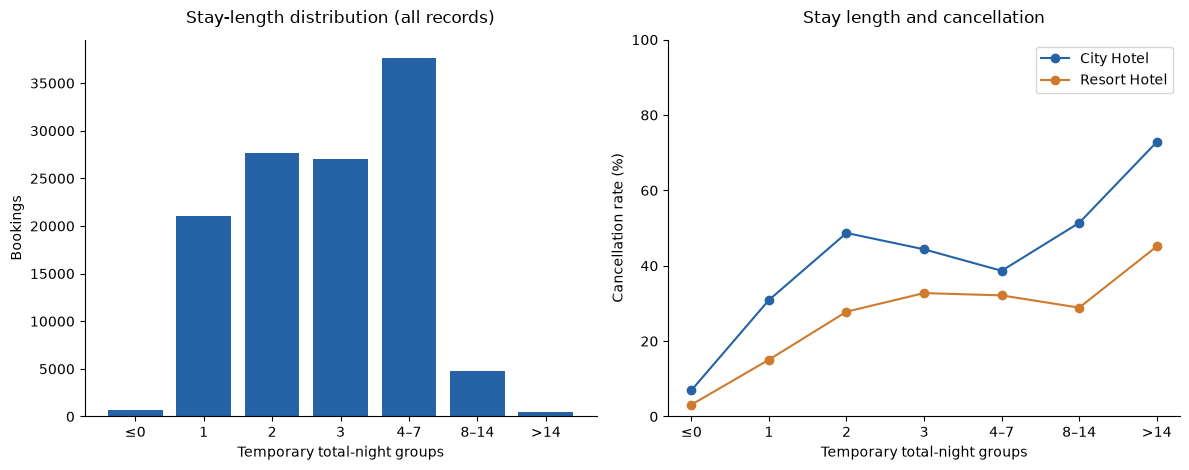

There are 715 zero-night records; none were removed. Median total stay: Cancelled 3, Not Cancelled 3. 1: 25.08% (n=21,020); 4–7: 35.90% (n=37,679).

In [7]:
total_stay_nights = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
display(numerical_summary(total_stay_nights).round(2))
stay_outcomes = outcome_summary(total_stay_nights)
display(stay_outcomes.round(2))
stay_groups = pd.cut(total_stay_nights, [-np.inf, 0, 1, 2, 3, 7, 14, np.inf], labels=["≤0", "1", "2", "3", "4–7", "8–14", ">14"])
stay_rates = rates(stay_groups)
stay_hotel_rates = rates(stay_groups, True)
show_rates(stay_rates)
show_rates(stay_hotel_rates)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].bar(stay_rates.index.astype(str), stay_rates["Bookings"], color=colours[0])
axes[0].set(title="Stay-length distribution (all records)", xlabel="Temporary total-night groups", ylabel="Bookings")
stay_pivot = stay_hotel_rates["Cancellation rate (%)"].unstack("hotel")
for hotel, colour in zip(hotel_order, colours):
    axes[1].plot(stay_pivot.index.astype(str), stay_pivot[hotel], marker="o", color=colour, label=hotel)
axes[1].set(title="Stay length and cancellation", xlabel="Temporary total-night groups", ylabel="Cancellation rate (%)", ylim=(0, 100))
axes[1].legend()
finish(fig, "stay_length_by_hotel.png")
findings["stay"] = (f"There are {int(total_stay_nights.eq(0).sum()):,} zero-night records; none were removed. "
    f"Median total stay: Cancelled {stay_outcomes.loc['Cancelled','median']:g}, Not Cancelled {stay_outcomes.loc['Not Cancelled','median']:g}. "
    + evidence(stay_rates, "1") + "; " + evidence(stay_rates, "4–7") + ".")
display(Markdown(findings["stay"]))

## 9 — Guest composition

Use direct addition so a missing guest component yields an unknown total, not a false zero. Temporary groupings describe count and the presence of recorded children/babies; they do not establish family relationships or define a model feature. Retain zero-guest records and report unknown totals.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,180,25,155,13.89,86.11,False
1,22581,6555,16026,29.03,70.97,False
2,82048,32569,49479,39.70,60.30,False
3,10494,3376,7118,32.17,67.83,False
4,3929,1646,2283,41.89,58.11,False
5+,154,49,105,31.82,68.18,False
NaN,4,4,0,100.00,0.00,True


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
No recorded children/babies,110054,40961,69093,37.22,62.78,False
Recorded children/babies present,9332,3259,6073,34.92,65.08,False
Unknown child/baby count,4,4,0,100.00,0.00,True


Bookings  Cancelled  \
hotel        Group                                                   
City Hotel   No recorded children/babies          73923      31236   
             Recorded children/babies present      5403       1862   
             Unknown child/baby count                 4          4   
Resort Hotel No recorded children/babies          36131       9725   
             Recorded children/babies present      3929       1397   

                                               Not Cancelled  \
hotel        Group                                             
City Hotel   No recorded children/babies               42687   
             Recorded children/babies present           3541   
             Unknown child/baby count                      0   
Resort Hotel No recorded children/babies               26406   
             Recorded children/babies present           2532   

                                               Cancellation rate (%)  \
hotel        Group                                                     
City Hotel   No recorded children/babies                       42.25   
             Recorded children/babies present                  34.46   
             Unknown child/baby count                         100.00   
Resort Hotel No recorded children/babies                       26.92   
             Recorded children/babies present                  35.56   

                                               Non-cancellation rate (%)  \
hotel        Group                                                         
City Hotel   No recorded children/babies                           57.75   
             Recorded children/babies present                      65.54   
             Unknown child/baby count                               0.00   
Resort Hotel No recorded children/babies                           73.08   
             Recorded children/babies present                      64.44   

                                               Small group (n < 100)  
hotel        Group                                                    
City Hotel   No recorded children/babies                       False  
             Recorded children/babies present                  False  
             Unknown child/baby count                           True  
Resort Hotel No recorded children/babies                       False  
             Recorded children/babies present                  False

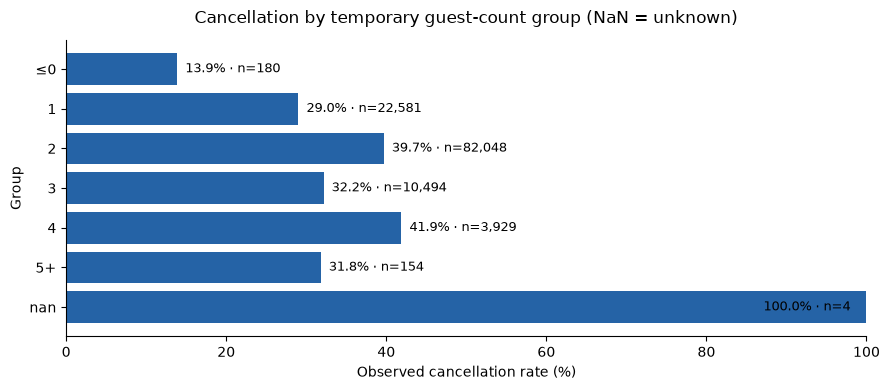

Zero total guests: 180; unknown guest totals: 4. No recorded children/babies: 37.22% (n=110,054); Recorded children/babies present: 34.92% (n=9,332).

In [8]:
total_guests = df["adults"] + df["children"] + df["babies"]
guest_groups = pd.cut(total_guests, [-np.inf, 0, 1, 2, 3, 4, np.inf], labels=["≤0", "1", "2", "3", "4", "5+"])
guest_rates = rates(guest_groups)
show_rates(guest_rates)
composition = pd.Series("Unknown child/baby count", index=df.index)
known_composition = df["children"].notna() & df["babies"].notna()
composition.loc[known_composition & (df["children"] + df["babies"]).eq(0)] = "No recorded children/babies"
composition.loc[known_composition & (df["children"] + df["babies"]).gt(0)] = "Recorded children/babies present"
composition_rates = rates(composition)
show_rates(composition_rates)
show_rates(rates(composition, True))
rate_plot(guest_rates, "Cancellation by temporary guest-count group (NaN = unknown)", "guest_composition_cancellation.png")
findings["guests"] = (f"Zero total guests: {int(total_guests.eq(0).sum()):,}; unknown guest totals: {int(total_guests.isna().sum()):,}. "
    + evidence(composition_rates, "No recorded children/babies") + "; " + evidence(composition_rates, "Recorded children/babies present") + ".")
display(Markdown(findings["guests"]))

## 10 — Customer history

Inspect the repeated-guest indicator and previous booking counts. History counts are highly concentrated, so temporary “0” versus “>0” groups keep the comparison readable without discarding sparse high counts. All rates remain unadjusted; history does not establish a cause.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
Not recorded as repeated,115580,43672,71908,37.79,62.21,False
Recorded as repeated,3810,552,3258,14.49,85.51,False


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                                          
City Hotel   Not recorded as repeated     77298      32661          44637   
             Recorded as repeated          2032        441           1591   
Resort Hotel Not recorded as repeated     38282      11011          27271   
             Recorded as repeated          1778        111           1667   

                                       Cancellation rate (%)  \
hotel        Group                                             
City Hotel   Not recorded as repeated                  42.25   
             Recorded as repeated                      21.70   
Resort Hotel Not recorded as repeated                  28.76   
             Recorded as repeated                       6.24   

                                       Non-cancellation rate (%)  \
hotel        Group                                                 
City Hotel   Not recorded as repeated                      57.75   
             Recorded as repeated                          78.30   
Resort Hotel Not recorded as repeated                      71.24   
             Recorded as repeated                          93.76   

                                       Small group (n < 100)  
hotel        Group                                            
City Hotel   Not recorded as repeated                  False  
             Recorded as repeated                      False  
Resort Hotel Not recorded as repeated                  False  
             Recorded as repeated                      False

,Value
count,119390.00
mean,0.09
std,0.84
min,0.00
25%,0.00
50%,0.00
75%,0.00
95%,1.00
99%,1.00
max,26.00


previous_cancellations


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,112906,38282,74624,33.91,66.09,False
>0,6484,5942,542,91.64,8.36,False


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   ≤0        73941      28084          45857                  37.98   
             >0         5389       5018            371                  93.12   
Resort Hotel ≤0        38965      10198          28767                  26.17   
             >0         1095        924            171                  84.38   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   ≤0                         62.02                  False  
             >0                          6.88                  False  
Resort Hotel ≤0                         73.83                  False  
             >0                         15.62                  False

,Value
count,119390.00
mean,0.14
std,1.50
min,0.00
25%,0.00
50%,0.00
75%,0.00
95%,0.00
99%,3.00
max,72.00


previous_bookings_not_canceled


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,115770,44024,71746,38.03,61.97,False
>0,3620,200,3420,5.52,94.48,False


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   ≤0        77742      32981          44761                  42.42   
             >0         1588        121           1467                   7.62   
Resort Hotel ≤0        38028      11043          26985                  29.04   
             >0         2032         79           1953                   3.89   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   ≤0                         57.58                  False  
             >0                         92.38                  False  
Resort Hotel ≤0                         70.96                  False  
             >0                         96.11                  False

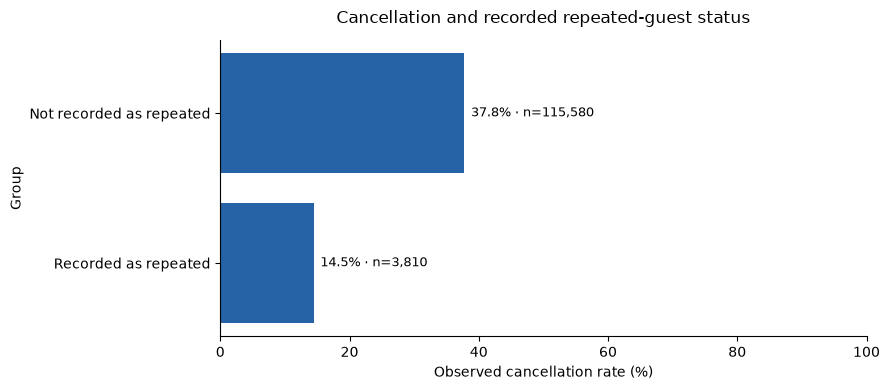

Not recorded as repeated: 37.79% (n=115,580); Recorded as repeated: 14.49% (n=3,810). Previous cancellations: ≤0: 33.91% (n=112,906); >0: 91.64% (n=6,484). Previous non-cancelled bookings: ≤0: 38.03% (n=115,770); >0: 5.52% (n=3,620).

In [9]:
repeat_labels = df["is_repeated_guest"].map({0: "Not recorded as repeated", 1: "Recorded as repeated"})
repeat_rates = rates(repeat_labels)
show_rates(repeat_rates)
show_rates(rates(repeat_labels, True))
history_tables = {}
for column in ["previous_cancellations", "previous_bookings_not_canceled"]:
    display(numerical_summary(df[column]).round(2))
    grouping = pd.cut(df[column], [-np.inf, 0, np.inf], labels=["≤0", ">0"])
    history_tables[column] = rates(grouping)
    print(column)
    show_rates(history_tables[column])
    show_rates(rates(grouping, True))
rate_plot(repeat_rates, "Cancellation and recorded repeated-guest status", "repeated_guest_cancellation.png")
findings["history"] = (evidence(repeat_rates, "Not recorded as repeated") + "; " + evidence(repeat_rates, "Recorded as repeated") +
    ". Previous cancellations: " + evidence(history_tables["previous_cancellations"], "≤0") + "; " + evidence(history_tables["previous_cancellations"], ">0") +
    ". Previous non-cancelled bookings: " + evidence(history_tables["previous_bookings_not_canceled"], "≤0") + "; " + evidence(history_tables["previous_bookings_not_canceled"], ">0") + ".")
display(Markdown(findings["history"]))

## 11 — Customer type

Inspect recorded customer categories and their hotel-specific distributions.

The tables show category frequency and both outcome rates, followed by the hotel breakdown. Small-group flags should be considered before interpreting extreme percentages.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
Contract,4076,1262,2814,30.96,69.04,False
Group,577,59,518,10.23,89.77,False
Transient,89613,36514,53099,40.75,59.25,False
Transient-Party,25124,6389,18735,25.43,74.57,False


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                                 
City Hotel   Contract             2300       1105           1195   
             Group                 293         29            264   
             Transient           59404      27098          32306   
             Transient-Party     17333       4870          12463   
Resort Hotel Contract             1776        157           1619   
             Group                 284         30            254   
             Transient           30209       9416          20793   
             Transient-Party      7791       1519           6272   

                              Cancellation rate (%)  \
hotel        Group                                    
City Hotel   Contract                         48.04   
             Group                             9.90   
             Transient                        45.62   
             Transient-Party                  28.10   
Resort Hotel Contract                          8.84   
             Group                            10.56   
             Transient                        31.17   
             Transient-Party                  19.50   

                              Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                              
City Hotel   Contract                             51.96                  False  
             Group                                90.10                  False  
             Transient                            54.38                  False  
             Transient-Party                      71.90                  False  
Resort Hotel Contract                             91.16                  False  
             Group                                89.44                  False  
             Transient                            68.83                  False  
             Transient-Party                      80.50                  False

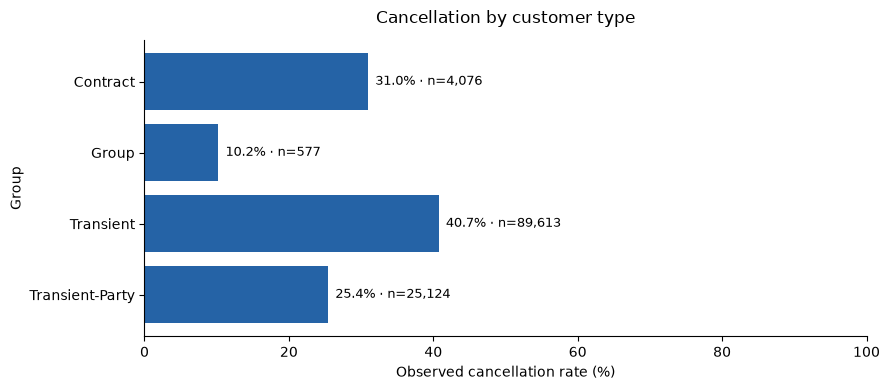

Among displayed categories with at least 100 records: Transient: 40.75% (n=89,613); Group: 10.23% (n=577). All categories contain at least 100 records.

In [10]:
customer_type_rates = rates(df["customer_type"])
customer_type_hotel_rates = rates(df["customer_type"], True)
show_rates(customer_type_rates)
show_rates(customer_type_hotel_rates)
rate_plot(customer_type_rates, "Cancellation by customer type", "customer_type_cancellation.png")
supported = customer_type_rates.loc[customer_type_rates["Bookings"] >= 100]
high = supported["Cancellation rate (%)"].idxmax()
low = supported["Cancellation rate (%)"].idxmin()
small_count = int((customer_type_rates["Bookings"] < 100).sum())
small_note = (f"{small_count} small category/categories remain in the tables; their rates are sensitive to small counts."
    if small_count else "All categories contain at least 100 records.")
findings["customer_type"] = ("Among displayed categories with at least 100 records: " + evidence(customer_type_rates, high) + "; " + evidence(customer_type_rates, low) + ". "
    + small_note)
display(Markdown(findings["customer_type"]))

## 12 — Market segment

Include all recorded segments, including Undefined, without treating them as errors. Compare major segments using hotel-specific denominators.

The tables show category frequency and both outcome rates, followed by the hotel breakdown. Small-group flags should be considered before interpreting extreme percentages.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
Aviation,237,52,185,21.94,78.06,False
Complementary,743,97,646,13.06,86.94,False
Corporate,5295,992,4303,18.73,81.27,False
Direct,12606,1934,10672,15.34,84.66,False
Groups,19811,12097,7714,61.06,38.94,False
Offline TA/TO,24219,8311,15908,34.32,65.68,False
Online TA,56477,20739,35738,36.72,63.28,False
Undefined,2,2,0,100.00,0.00,True


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                               
City Hotel   Aviation            237         52            185   
             Complementary       542         64            478   
             Corporate          2986        641           2345   
             Direct             6093       1056           5037   
             Groups            13975       9623           4352   
             Offline TA/TO     16747       7173           9574   
             Online TA         38748      14491          24257   
             Undefined             2          2              0   
Resort Hotel Complementary       201         33            168   
             Corporate          2309        351           1958   
             Direct             6513        878           5635   
             Groups             5836       2474           3362   
             Offline TA/TO      7472       1138           6334   
             Online TA         17729       6248          11481   

                            Cancellation rate (%)  Non-cancellation rate (%)  \
hotel        Group                                                             
City Hotel   Aviation                       21.94                      78.06   
             Complementary                  11.81                      88.19   
             Corporate                      21.47                      78.53   
             Direct                         17.33                      82.67   
             Groups                         68.86                      31.14   
             Offline TA/TO                  42.83                      57.17   
             Online TA                      37.40                      62.60   
             Undefined                     100.00                       0.00   
Resort Hotel Complementary                  16.42                      83.58   
             Corporate                      15.20                      84.80   
             Direct                         13.48                      86.52   
             Groups                         42.39                      57.61   
             Offline TA/TO                  15.23                      84.77   
             Online TA                      35.24                      64.76   

                            Small group (n < 100)  
hotel        Group                                 
City Hotel   Aviation                       False  
             Complementary                  False  
             Corporate                      False  
             Direct                         False  
             Groups                         False  
             Offline TA/TO                  False  
             Online TA                      False  
             Undefined                       True  
Resort Hotel Complementary                  False  
             Corporate                      False  
             Direct                         False  
             Groups                         False  
             Offline TA/TO                  False  
             Online TA                      False

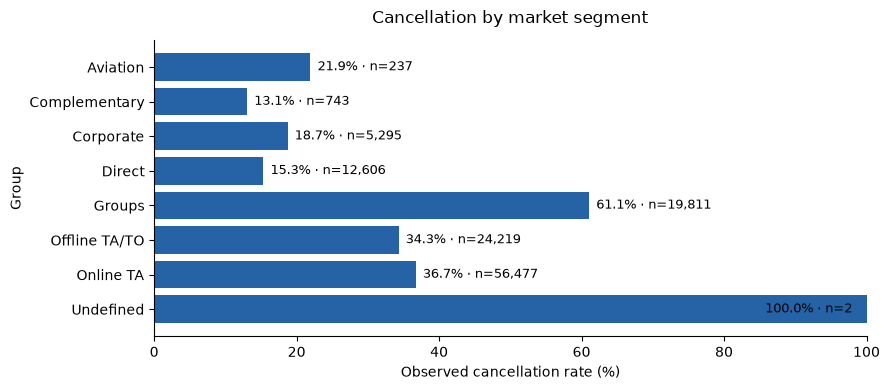

Among displayed categories with at least 100 records: Groups: 61.06% (n=19,811); Complementary: 13.06% (n=743). 1 small category/categories remain in the tables; their rates are sensitive to small counts.

In [11]:
market_segment_rates = rates(df["market_segment"])
market_segment_hotel_rates = rates(df["market_segment"], True)
show_rates(market_segment_rates)
show_rates(market_segment_hotel_rates)
rate_plot(market_segment_rates, "Cancellation by market segment", "market_segment_cancellation.png")
supported = market_segment_rates.loc[market_segment_rates["Bookings"] >= 100]
high = supported["Cancellation rate (%)"].idxmax()
low = supported["Cancellation rate (%)"].idxmin()
small_count = int((market_segment_rates["Bookings"] < 100).sum())
small_note = (f"{small_count} small category/categories remain in the tables; their rates are sensitive to small counts."
    if small_count else "All categories contain at least 100 records.")
findings["market_segment"] = ("Among displayed categories with at least 100 records: " + evidence(market_segment_rates, high) + "; " + evidence(market_segment_rates, low) + ". "
    + small_note)
display(Markdown(findings["market_segment"]))

## 13 — Distribution channel

Use tables to inspect channel patterns without adding another chart that largely repeats the market-segment comparison.

The tables show category frequency and both outcome rates, followed by the hotel breakdown. Small-group flags should be considered before interpreting extreme percentages.

In [12]:
distribution_channel_rates = rates(df["distribution_channel"])
distribution_channel_hotel_rates = rates(df["distribution_channel"], True)
show_rates(distribution_channel_rates)
show_rates(distribution_channel_hotel_rates)
supported = distribution_channel_rates.loc[distribution_channel_rates["Bookings"] >= 100]
high = supported["Cancellation rate (%)"].idxmax()
low = supported["Cancellation rate (%)"].idxmin()
small_count = int((distribution_channel_rates["Bookings"] < 100).sum())
small_note = (f"{small_count} small category/categories remain in the tables; their rates are sensitive to small counts."
    if small_count else "All categories contain at least 100 records.")
findings["distribution_channel"] = ("Among displayed categories with at least 100 records: " + evidence(distribution_channel_rates, high) + "; " + evidence(distribution_channel_rates, low) + ". "
    + small_note)
display(Markdown(findings["distribution_channel"]))

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
Corporate,6677,1474,5203,22.08,77.92,False
Direct,14645,2557,12088,17.46,82.54,False
GDS,193,37,156,19.17,80.83,False
TA/TO,97870,40152,57718,41.03,58.97,False
Undefined,5,4,1,80.00,20.00,True


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                           
City Hotel   Corporate      3408        786           2622   
             Direct         6780       1232           5548   
             GDS             193         37            156   
             TA/TO         68945      31043          37902   
             Undefined         4          4              0   
Resort Hotel Corporate      3269        688           2581   
             Direct         7865       1325           6540   
             TA/TO         28925       9109          19816   
             Undefined         1          0              1   

                        Cancellation rate (%)  Non-cancellation rate (%)  \
hotel        Group                                                         
City Hotel   Corporate                  23.06                      76.94   
             Direct                     18.17                      81.83   
             GDS                        19.17                      80.83   
             TA/TO                      45.03                      54.97   
             Undefined                 100.00                       0.00   
Resort Hotel Corporate                  21.05                      78.95   
             Direct                     16.85                      83.15   
             TA/TO                      31.49                      68.51   
             Undefined                   0.00                     100.00   

                        Small group (n < 100)  
hotel        Group                             
City Hotel   Corporate                  False  
             Direct                     False  
             GDS                        False  
             TA/TO                      False  
             Undefined                   True  
Resort Hotel Corporate                  False  
             Direct                     False  
             TA/TO                      False  
             Undefined                   True

Among displayed categories with at least 100 records: TA/TO: 41.03% (n=97,870); Direct: 17.46% (n=14,645). 1 small category/categories remain in the tables; their rates are sensitive to small counts.

## 14 — Deposit type

A strong descriptive association does not establish causation or approve a feature for prediction. Deposit timing and category meaning need context; no treatment is selected.

The tables show category frequency and both outcome rates, followed by the hotel breakdown. Small-group flags should be considered before interpreting extreme percentages.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
No Deposit,104641,29694,74947,28.38,71.62,False
Non Refund,14587,14494,93,99.36,0.64,False
Refundable,162,36,126,22.22,77.78,False


Bookings  Cancelled  Not Cancelled  \
hotel        Group                                            
City Hotel   No Deposit     66442      20244          46198   
             Non Refund     12868      12844             24   
             Refundable        20         14              6   
Resort Hotel No Deposit     38199       9450          28749   
             Non Refund      1719       1650             69   
             Refundable       142         22            120   

                         Cancellation rate (%)  Non-cancellation rate (%)  \
hotel        Group                                                          
City Hotel   No Deposit                  30.47                      69.53   
             Non Refund                  99.81                       0.19   
             Refundable                  70.00                      30.00   
Resort Hotel No Deposit                  24.74                      75.26   
             Non Refund                  95.99                       4.01   
             Refundable                  15.49                      84.51   

                         Small group (n < 100)  
hotel        Group                              
City Hotel   No Deposit                  False  
             Non Refund                  False  
             Refundable                   True  
Resort Hotel No Deposit                  False  
             Non Refund                  False  
             Refundable                  False

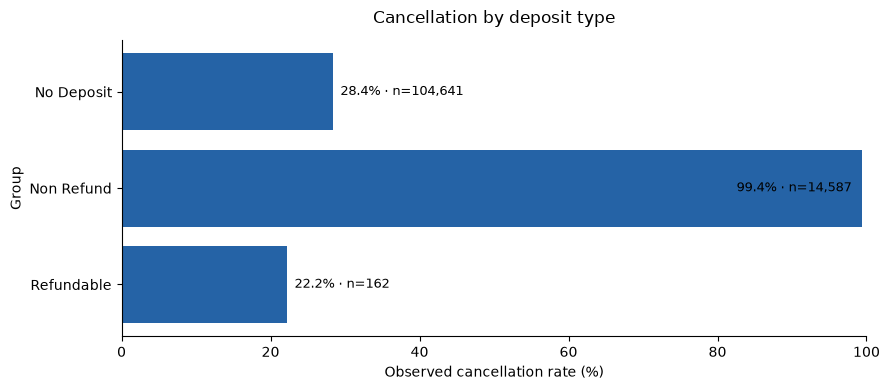

Among displayed categories with at least 100 records: Non Refund: 99.36% (n=14,587); Refundable: 22.22% (n=162). All categories contain at least 100 records.

In [13]:
deposit_type_rates = rates(df["deposit_type"])
deposit_type_hotel_rates = rates(df["deposit_type"], True)
show_rates(deposit_type_rates)
show_rates(deposit_type_hotel_rates)
rate_plot(deposit_type_rates, "Cancellation by deposit type", "deposit_type_cancellation.png")
supported = deposit_type_rates.loc[deposit_type_rates["Bookings"] >= 100]
high = supported["Cancellation rate (%)"].idxmax()
low = supported["Cancellation rate (%)"].idxmin()
small_count = int((deposit_type_rates["Bookings"] < 100).sum())
small_note = (f"{small_count} small category/categories remain in the tables; their rates are sensitive to small counts."
    if small_count else "All categories contain at least 100 records.")
findings["deposit_type"] = ("Among displayed categories with at least 100 records: " + evidence(deposit_type_rates, high) + "; " + evidence(deposit_type_rates, low) + ". "
    + small_note)
display(Markdown(findings["deposit_type"]))

## 15 — Special requests

Inspect request frequencies and observed cancellation rates. Hotel-specific tables separate these associations from the combined hotel mix.

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
0,70318,33556,36762,47.72,52.28,False
1,33226,7318,25908,22.02,77.98,False
2,12969,2866,10103,22.10,77.90,False
3,2497,446,2051,17.86,82.14,False
4,340,36,304,10.59,89.41,False
5,40,2,38,5.00,95.00,True


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   0         47957      26340          21617                  54.92   
             1         21420       4721          16699                  22.04   
             2          8142       1739           6403                  21.36   
             3          1587        280           1307                  17.64   
             4           198         21            177                  10.61   
             5            26          1             25                   3.85   
Resort Hotel 0         22361       7216          15145                  32.27   
             1         11806       2597           9209                  22.00   
             2          4827       1127           3700                  23.35   
             3           910        166            744                  18.24   
             4           142         15            127                  10.56   
             5            14          1             13                   7.14   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   0                          45.08                  False  
             1                          77.96                  False  
             2                          78.64                  False  
             3                          82.36                  False  
             4                          89.39                  False  
             5                          96.15                   True  
Resort Hotel 0                          67.73                  False  
             1                          78.00                  False  
             2                          76.65                  False  
             3                          81.76                  False  
             4                          89.44                  False  
             5                          92.86                   True

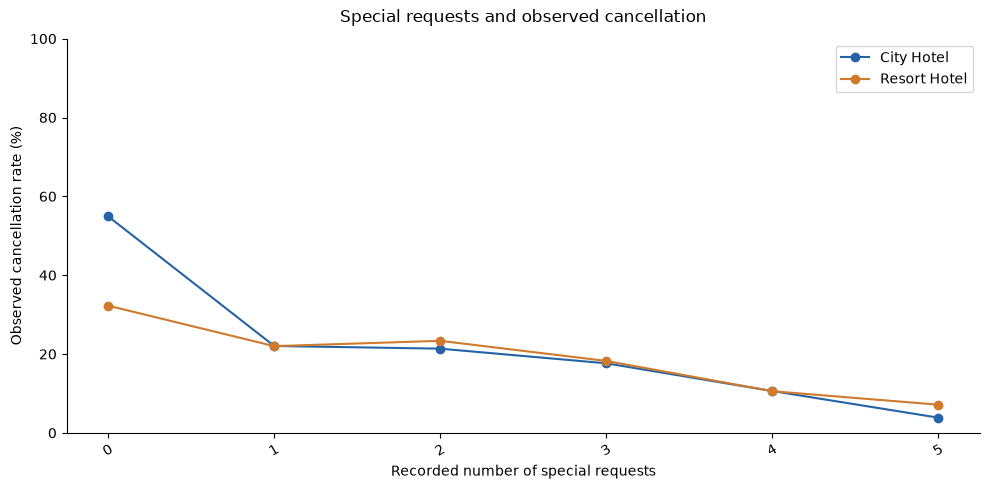

0: 47.72% (n=70,318); 1: 22.02% (n=33,226); 2: 22.10% (n=12,969). Request counts are associated with different observed rates; no causal interpretation is made.

In [14]:
request_rates = rates(df["total_of_special_requests"])
request_hotel_rates = rates(df["total_of_special_requests"], True)
show_rates(request_rates)
show_rates(request_hotel_rates)
hotel_rate_plot(request_hotel_rates, "Special requests and observed cancellation", "Recorded number of special requests", "special_requests_by_hotel.png")
findings["requests"] = evidence(request_rates, 0) + "; " + evidence(request_rates, 1) + "; " + evidence(request_rates, 2) + ". Request counts are associated with different observed rates; no causal interpretation is made."
display(Markdown(findings["requests"]))

## 16 — ADR analysis

Show the full observed range with logarithmic count scale, plus a zoom of the central 1st–99th percentile range with within-hotel density curves. The zoom changes the displayed subset only: **records outside its range are not removed from `df` or full-data summaries**. Report their count. Use common histogram bins for the hotel comparison; density describes distribution shape rather than hotel size. No currency or ADR construction is assumed here.

,Value
count,119390.00
mean,101.83
std,50.54
min,-6.38
25%,69.29
50%,94.58
75%,126.00
95%,193.50
99%,252.00
max,5400.00


,count,mean,median,min,max
is_canceled,,,,,
Not Cancelled,75166,99.99,92.5,-6.38,510.0
Cancelled,44224,104.96,96.2,0.00,5400.0


count    mean  median   min     max
hotel        is_canceled                                     
City Hotel   0            46228  105.75    99.9  0.00   510.0
             1            33102  104.69    99.8  0.00  5400.0
Resort Hotel 0            28938   90.79    72.0 -6.38   508.0
             1            11122  105.79    84.0  0.00   450.0

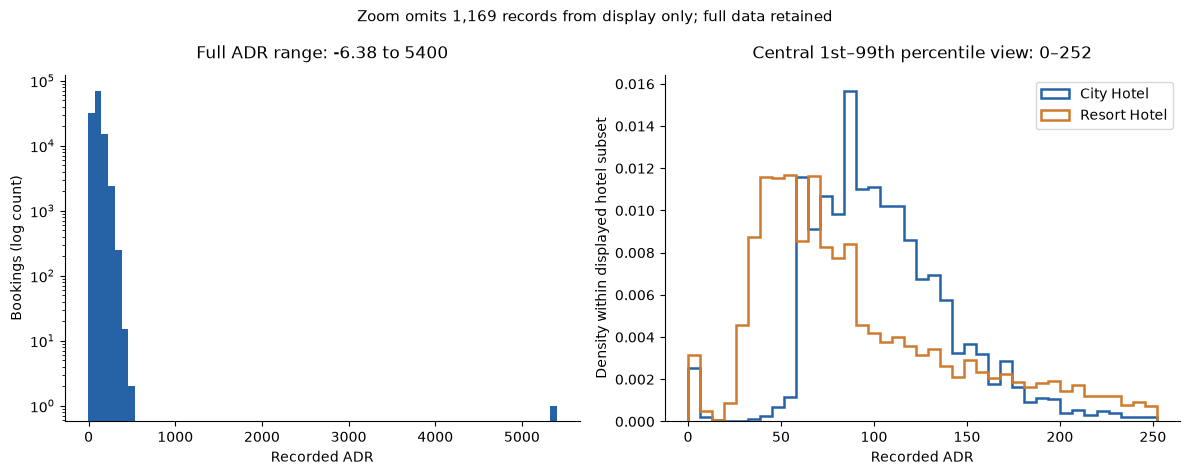

ADR range -6.38–5400; median ADR for Cancelled 96.20, Not Cancelled 92.50. The zoom shows 0–252; 1,169 records outside it remain in all full-data calculations. This aggregate comparison does not adjust for hotel or arrival period.

In [15]:
display(numerical_summary(df["adr"]).round(2))
adr_outcomes = outcome_summary(df["adr"])
display(adr_outcomes.round(2))
display(df.groupby(["hotel", "is_canceled"])["adr"].agg(["count", "mean", "median", "min", "max"]).round(2))
adr_low, adr_high = df["adr"].quantile([0.01, 0.99])
adr_outside = df["adr"].notna() & ~df["adr"].between(adr_low, adr_high)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].hist(df["adr"], bins=70, color=colours[0])
axes[0].set(yscale="log", title=f"Full ADR range: {df['adr'].min():g} to {df['adr'].max():g}", xlabel="Recorded ADR", ylabel="Bookings (log count)")
for hotel, colour in zip(hotel_order, colours):
    view = df.loc[df["hotel"].eq(hotel) & df["adr"].between(adr_low, adr_high), "adr"]
    axes[1].hist(view, bins=np.linspace(adr_low, adr_high, 40), density=True, histtype="step", linewidth=1.8, color=colour, label=hotel)
axes[1].set(title=f"Central 1st–99th percentile view: {adr_low:g}–{adr_high:g}", xlabel="Recorded ADR", ylabel="Density within displayed hotel subset")
axes[1].legend()
fig.suptitle(f"Zoom omits {int(adr_outside.sum()):,} records from display only; full data retained", fontsize=11)
finish(fig, "adr_full_range_and_central_view.png")
findings["adr"] = (f"ADR range {df['adr'].min():g}–{df['adr'].max():g}; median ADR for Cancelled {adr_outcomes.loc['Cancelled','median']:.2f}, "
    f"Not Cancelled {adr_outcomes.loc['Not Cancelled','median']:.2f}. "
    f"The zoom shows {adr_low:g}–{adr_high:g}; {int(adr_outside.sum()):,} records outside it remain in all full-data calculations. "
    "This aggregate comparison does not adjust for hotel or arrival period.")
display(Markdown(findings["adr"]))

## 17 — Reserved room type

Inspect reserved room codes without inventing code meanings. `assigned_room_type` remains in the raw data but is not evaluated as an approved predictive feature; availability and leakage require a separate audit.

The tables show category frequency and both outcome rates, followed by the hotel breakdown. Small-group flags should be considered before interpreting extreme percentages.

In [16]:
reserved_room_type_rates = rates(df["reserved_room_type"])
reserved_room_type_hotel_rates = rates(df["reserved_room_type"], True)
show_rates(reserved_room_type_rates)
show_rates(reserved_room_type_hotel_rates)
supported = reserved_room_type_rates.loc[reserved_room_type_rates["Bookings"] >= 100]
high = supported["Cancellation rate (%)"].idxmax()
low = supported["Cancellation rate (%)"].idxmin()
small_count = int((reserved_room_type_rates["Bookings"] < 100).sum())
small_note = (f"{small_count} small category/categories remain in the tables; their rates are sensitive to small counts."
    if small_count else "All categories contain at least 100 records.")
findings["reserved_room_type"] = ("Among displayed categories with at least 100 records: " + evidence(reserved_room_type_rates, high) + "; " + evidence(reserved_room_type_rates, low) + ". "
    + small_note)
display(Markdown(findings["reserved_room_type"]))

,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
A,85994,33630,52364,39.11,60.89,False
B,1118,368,750,32.92,67.08,False
C,932,308,624,33.05,66.95,False
D,19201,6102,13099,31.78,68.22,False
E,6535,1914,4621,29.29,70.71,False
F,2897,880,2017,30.38,69.62,False
G,2094,763,1331,36.44,63.56,False
H,601,245,356,40.77,59.23,False
L,6,2,4,33.33,66.67,True


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   A         62595      27248          35347                  43.53   
             B          1115        368            747                  33.00   
             C            14          5              9                  35.71   
             D         11768       4147           7621                  35.24   
             E          1553        505           1048                  32.52   
             F          1791        700           1091                  39.08   
             G           484        119            365                  24.59   
             P            10         10              0                 100.00   
Resort Hotel A         23399       6382          17017                  27.27   
             B             3          0              3                   0.00   
             C           918        303            615                  33.01   
             D          7433       1955           5478                  26.30   
             E          4982       1409           3573                  28.28   
             F          1106        180            926                  16.27   
             G          1610        644            966                  40.00   
             H           601        245            356                  40.77   
             L             6          2              4                  33.33   
             P             2          2              0                 100.00   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   A                          56.47                  False  
             B                          67.00                  False  
             C                          64.29                   True  
             D                          64.76                  False  
             E                          67.48                  False  
             F                          60.92                  False  
             G                          75.41                  False  
             P                           0.00                   True  
Resort Hotel A                          72.73                  False  
             B                         100.00                   True  
             C                          66.99                  False  
             D                          73.70                  False  
             E                          71.72                  False  
             F                          83.73                  False  
             G                          60.00                  False  
             H                          59.23                  False  
             L                          66.67                   True  
             P                           0.00                   True

Among displayed categories with at least 100 records: H: 40.77% (n=601); E: 29.29% (n=6,535). 2 small category/categories remain in the tables; their rates are sensitive to small counts.

## 18 — Parking, waiting list, and booking changes

Descriptively inspect operational counts using temporary 0 versus positive groups, while retaining their full numerical ranges in summaries. **Booking changes: Pending leakage audit.** Neither these summaries nor any association approves the timing-sensitive fields as predictors.

In [17]:
operational_tables = {}
for column in ["required_car_parking_spaces", "days_in_waiting_list", "booking_changes"]:
    print(column + (" — Pending leakage audit" if column == "booking_changes" else ""))
    display(numerical_summary(df[column]).round(2))
    groups = pd.cut(df[column], [-np.inf, 0, np.inf], labels=["≤0", ">0"])
    operational_tables[column] = rates(groups)
    show_rates(operational_tables[column])
    show_rates(rates(groups, True))
findings["operations"] = "Parking: " + evidence(operational_tables["required_car_parking_spaces"], "≤0") + "; " + evidence(operational_tables["required_car_parking_spaces"], ">0") + ". Booking-changes timing remains pending leakage audit."
display(Markdown(findings["operations"]))

required_car_parking_spaces


,Value
count,119390.00
mean,0.06
std,0.25
min,0.00
25%,0.00
50%,0.00
75%,0.00
95%,1.00
99%,1.00
max,8.00


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,111974,44224,67750,39.49,60.51,False
>0,7416,0,7416,0.00,100.00,False


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   ≤0        77404      33102          44302                  42.77   
             >0         1926          0           1926                   0.00   
Resort Hotel ≤0        34570      11122          23448                  32.17   
             >0         5490          0           5490                   0.00   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   ≤0                         57.23                  False  
             >0                        100.00                  False  
Resort Hotel ≤0                         67.83                  False  
             >0                        100.00                  False

days_in_waiting_list


...

booking_changes — Pending leakage audit


,Value
count,119390.00
mean,0.22
std,0.65
min,0.00
25%,0.00
50%,0.00
75%,0.00
95%,1.00
99%,3.00
max,21.00


,Bookings,Cancelled,Not Cancelled,Cancellation rate (%),Non-cancellation rate (%),Small group (n < 100)
Group,,,,,,
≤0,101314,41391,59923,40.85,59.15,False
>0,18076,2833,15243,15.67,84.33,False


Bookings  Cancelled  Not Cancelled  Cancellation rate (%)  \
hotel        Group                                                              
City Hotel   ≤0        69062      31423          37639                  45.50   
             >0        10268       1679           8589                  16.35   
Resort Hotel ≤0        32252       9968          22284                  30.91   
             >0         7808       1154           6654                  14.78   

                    Non-cancellation rate (%)  Small group (n < 100)  
hotel        Group                                                    
City Hotel   ≤0                         54.50                  False  
             >0                         83.65                  False  
Resort Hotel ≤0                         69.09                  False  
             >0                         85.22                  False

Parking: ≤0: 39.49% (n=111,974); >0: 0.00% (n=7,416). Booking-changes timing remains pending leakage audit.

## 19 — Features reserved for leakage audit

`reservation_status` and `reservation_status_date` are intentionally not analysed as candidate predictors because their relationship to the outcome and their timing raise target-revealing concerns. `assigned_room_type`, `booking_changes`, and other timing-sensitive fields will also be reviewed against a realistic prediction time.

No columns are removed here. No final use/drop decision or final leakage-removal list is established. Descriptive associations elsewhere in this notebook do not approve a variable for prediction.

## 20 — City Hotel versus Resort Hotel comparison summary

Consolidate reliably calculated measures. Temporary stay totals are used only for this summary. Rates and means use each hotel’s records; numerical medians describe observed non-null values.

In [18]:
hotel_summary = pd.DataFrame(index=hotel_order)
hotel_summary.index.name = "Hotel"
hotel_summary["Records"] = df.groupby("hotel").size()
hotel_summary["Cancellation rate (%)"] = 100 * df.groupby("hotel")["is_canceled"].mean()
hotel_summary["Median lead time"] = df.groupby("hotel")["lead_time"].median()
hotel_summary["Median ADR"] = df.groupby("hotel")["adr"].median()
hotel_summary["Mean stay nights"] = total_stay_nights.groupby(df["hotel"]).mean()
hotel_summary["Median stay nights"] = total_stay_nights.groupby(df["hotel"]).median()
hotel_summary["Repeated-guest proportion (%)"] = 100 * df["is_repeated_guest"].eq(1).groupby(df["hotel"]).mean()
hotel_summary["Mean special requests"] = df.groupby("hotel")["total_of_special_requests"].mean()
display(hotel_summary.round(2))
c, r = hotel_summary.loc["City Hotel"], hotel_summary.loc["Resort Hotel"]
findings["comparison"] = (f"City/Resort medians: lead time {c['Median lead time']:g}/{r['Median lead time']:g}, "
    f"ADR {c['Median ADR']:.2f}/{r['Median ADR']:.2f}, stay {c['Median stay nights']:g}/{r['Median stay nights']:g} nights. "
    f"Mean stay is {c['Mean stay nights']:.2f}/{r['Mean stay nights']:.2f} nights and repeated-guest share is "
    f"{c['Repeated-guest proportion (%)']:.2f}%/{r['Repeated-guest proportion (%)']:.2f}%. "
    f"Mean special requests are comparatively close at {c['Mean special requests']:.2f}/{r['Mean special requests']:.2f}. "
    "The cancellation-rate, lead-time, and stay differences support continuing hotel-specific investigation, but cannot predict whether separate models will outperform a general model.")
display(Markdown(findings["comparison"]))

,Records,Cancellation rate (%),Median lead time,Median ADR,Mean stay nights,Median stay nights,Repeated-guest proportion (%),Mean special requests
Hotel,,,,,,,,
City Hotel,79330,41.73,74.0,99.9,2.98,3.0,2.56,0.55
Resort Hotel,40060,27.76,57.0,75.0,4.32,3.0,4.44,0.62


City/Resort medians: lead time 74/57, ADR 99.90/75.00, stay 3/3 nights. Mean stay is 2.98/4.32 nights and repeated-guest share is 2.56%/4.44%. Mean special requests are comparatively close at 0.55/0.62. The cancellation-rate, lead-time, and stay differences support continuing hotel-specific investigation, but cannot predict whether separate models will outperform a general model.

## 21 — Key EDA findings

The summary below is generated from this run’s calculated evidence. All comparisons retain raw-data quality issues and are unadjusted associations.

In [19]:
findings["quality"] = (f"All {int(df.duplicated().sum()):,} extra identical rows remain. "
    f"Zero guests: {int(total_guests.eq(0).sum()):,}; zero stays: {int(total_stay_nights.eq(0).sum()):,}; "
    f"unknown guest totals: {int(total_guests.isna().sum()):,}. ADR includes {int(df['adr'].lt(0).sum()):,} negative "
    f"and {int(df['adr'].eq(0).sum()):,} zero values. No records have been cleaned or excluded from full-data summaries. "
    "Sparse categories and skewed distributions require contextual review; the earlier quality audit remains the detailed source.")
summary_sections = {
    "Target distribution": ["target"],
    "City Hotel vs Resort Hotel": ["hotel_rates", "comparison"],
    "Booking timing": ["lead", "months"],
    "Customer behaviour/history": ["history", "customer_type"],
    "Reservation characteristics": ["market_segment", "deposit_type", "requests", "stay", "adr"],
    "Unusual observations relevant to preprocessing": ["quality"],
}
for title, keys in summary_sections.items():
    display(Markdown("### " + title + "\n\n" + "\n\n".join(findings[key] for key in keys)))

### Target distribution

Not Cancelled: 75,166 (62.96%); Cancelled: 44,224 (37.04%). The class distribution is not perfectly balanced. No resampling decision is made.

### City Hotel vs Resort Hotel

City Hotel: 41.73%; Resort Hotel: 27.76%. City minus Resort is 13.96 percentage points. This descriptive difference motivates hotel-specific investigation; it does not establish significance, causation, or model superiority.

City/Resort medians: lead time 74/57, ADR 99.90/75.00, stay 3/3 nights. Mean stay is 2.98/4.32 nights and repeated-guest share is 2.56%/4.44%. Mean special requests are comparatively close at 0.55/0.62. The cancellation-rate, lead-time, and stay differences support continuing hotel-specific investigation, but cannot predict whether separate models will outperform a general model.

### Booking timing

Median lead time is 113 for Cancelled and 45 for Not Cancelled records. 1–7: 10.98% (n=13,401); 181–365: 55.45% (n=21,544). These are unadjusted associations.

Pooled monthly extremes: June: 41.46% (n=10,939); January: 30.48% (n=5,929). Observed months per year: 2015: 6; 2016: 12; 2017: 8. Unequal month coverage and hotel composition limit a seasonal interpretation.

### Customer behaviour/history

Not recorded as repeated: 37.79% (n=115,580); Recorded as repeated: 14.49% (n=3,810). Previous cancellations: ≤0: 33.91% (n=112,906); >0: 91.64% (n=6,484). Previous non-cancelled bookings: ≤0: 38.03% (n=115,770); >0: 5.52% (n=3,620).

Among displayed categories with at least 100 records: Transient: 40.75% (n=89,613); Group: 10.23% (n=577). All categories contain at least 100 records.

### Reservation characteristics

Among displayed categories with at least 100 records: Groups: 61.06% (n=19,811); Complementary: 13.06% (n=743). 1 small category/categories remain in the tables; their rates are sensitive to small counts.

Among displayed categories with at least 100 records: Non Refund: 99.36% (n=14,587); Refundable: 22.22% (n=162). All categories contain at least 100 records.

0: 47.72% (n=70,318); 1: 22.02% (n=33,226); 2: 22.10% (n=12,969). Request counts are associated with different observed rates; no causal interpretation is made.

There are 715 zero-night records; none were removed. Median total stay: Cancelled 3, Not Cancelled 3. 1: 25.08% (n=21,020); 4–7: 35.90% (n=37,679).

ADR range -6.38–5400; median ADR for Cancelled 96.20, Not Cancelled 92.50. The zoom shows 0–252; 1,169 records outside it remain in all full-data calculations. This aggregate comparison does not adjust for hotel or arrival period.

### Unusual observations relevant to preprocessing

All 31,994 extra identical rows remain. Zero guests: 180; zero stays: 715; unknown guest totals: 4. ADR includes 1 negative and 1,959 zero values. No records have been cleaned or excluded from full-data summaries. Sparse categories and skewed distributions require contextual review; the earlier quality audit remains the detailed source.

## 22 — Implications for next stages

Record follow-up questions without prescribing final treatments. Hotel-specific modelling remains an experimental question for a later project stage.

In [20]:
implications = pd.DataFrame([
    {"EDA Observation": findings["hotel_rates"], "Why It Matters": "Hotel mix may affect aggregate patterns.", "Next Stage to Investigate": "Model development later: compare general and hotel-specific approaches"},
    {"EDA Observation": findings["lead"], "Why It Matters": "Booking timing differs across observed outcomes; ranges and skew need context.", "Next Stage to Investigate": "Preprocessing and model-specific feature representation"},
    {"EDA Observation": findings["deposit_type"], "Why It Matters": "A strong unadjusted association does not establish availability at prediction time.", "Next Stage to Investigate": "Data leakage audit; feature selection later"},
    {"EDA Observation": findings["stay"], "Why It Matters": "Stay totals may be useful, but zero-night records need interpretation.", "Next Stage to Investigate": "Preprocessing and feature engineering"},
    {"EDA Observation": findings["quality"], "Why It Matters": "Duplicates and unusual or missing values can affect raw descriptive summaries.", "Next Stage to Investigate": "Preprocessing with justified decisions"},
    {"EDA Observation": findings["months"], "Why It Matters": "Partial-year coverage can influence pooled month patterns.", "Next Stage to Investigate": "Feature engineering and evaluation design later"},
])
with pd.option_context("display.max_colwidth", 100):
    display(implications)

def markdown_table(table):
    def text(value):
        if pd.isna(value):
            return "N/A"
        return f"{value:.2f}" if isinstance(value, float) else str(value)
    lines = ["| " + " | ".join(table.columns) + " |", "| " + " | ".join("---" for _ in table.columns) + " |"]
    lines += ["| " + " | ".join(text(value) for value in row) + " |" for row in table.itertuples(index=False, name=None)]
    return "\n".join(lines)

report_markdown = (
    "# Exploratory Data Analysis Findings\n\n"
    f"Source: `data/raw/hotel_bookings.csv`, {len(df):,} records × {len(df.columns)} columns. "
    "Calculated in `notebooks/03_exploratory_data_analysis.ipynb`. All results are descriptive, unadjusted, and based on raw records. "
    "No preprocessing or model development has been performed. Rates use within-group denominators; sample sizes are shown with comparisons.\n\n"
    "## Target Distribution\n\n" + findings["target"] + "\n\n"
    "## City Hotel vs Resort Hotel\n\n" + findings["hotel_rates"] + "\n\n"
    + markdown_table(hotel_summary.round(2).reset_index()) + "\n\n" + findings["comparison"] + "\n\n"
    "## Important Cancellation Patterns\n\n"
    + "\n\n".join("**" + title + ":** " + findings[key] for title, key in [
        ("Lead time", "lead"), ("Arrival month", "months"), ("Customer history", "history"),
        ("Customer type", "customer_type"), ("Market segment", "market_segment"), ("Deposit type", "deposit_type"),
        ("Special requests", "requests"), ("Stay length", "stay"), ("ADR", "adr")]) + "\n\n"
    "## Data Quality Observations Reinforced by EDA\n\n" + findings["quality"] + "\n\n"
    "## Implications for Preprocessing\n\n"
    "- Review missingness, repeated rows, zero totals, and unusual ADR values before deciding any treatment.\n"
    "- Assess skew and sparse groups in the context of later model requirements; no scaling, resampling, or category regrouping is approved here.\n"
    "- Evaluate temporary lead-time, guest, and stay calculations as possible representations later; none has been added to the raw data.\n"
    "- Account for incomplete annual coverage when investigating arrival patterns.\n"
    "- Review feature timing separately, including reservation_status, reservation_status_date, assigned_room_type, booking_changes, and other timing-sensitive fields. No columns were removed.\n\n"
    "## Implications for Project Novelty\n\n"
    + findings["comparison"] + " The observed differences justify continuing the proposed investigation; they do not establish statistical significance, causation, or a modelling advantage.\n\n"
    f"{len(figure_names)} figures were generated locally under `reports/figures/` (Git-ignored)."
    " Tables retain small groups; extreme rates in those groups should not be overinterpreted.\n"
)

# Verify integrity without changing any data or writing a processed dataset.
pd.testing.assert_frame_equal(df, pd.read_csv(data_path))
assert hashlib.sha256(data_path.read_bytes()).hexdigest() == raw_hash_before
print(f"Integrity verified: raw CSV and DataFrame unchanged; {len(figure_names)} figures saved under reports/figures/.")

,EDA Observation,Why It Matters,Next Stage to Investigate
0,City Hotel: 41.73%; Resort Hotel: 27.76%. City minus Resort is 13.96 percentage points. This des...,Hotel mix may affect aggregate patterns.,Model development later: compare general and hotel-specific approaches
1,"Median lead time is 113 for Cancelled and 45 for Not Cancelled records. 1–7: 10.98% (n=13,401); ...",Booking timing differs across observed outcomes; ranges and skew need context.,Preprocessing and model-specific feature representation
2,"Among displayed categories with at least 100 records: Non Refund: 99.36% (n=14,587); Refundable:...",A strong unadjusted association does not establish availability at prediction time.,Data leakage audit; feature selection later
3,"There are 715 zero-night records; none were removed. Median total stay: Cancelled 3, Not Cancell...","Stay totals may be useful, but zero-night records need interpretation.",Preprocessing and feature engineering
4,"All 31,994 extra identical rows remain. Zero guests: 180; zero stays: 715; unknown guest totals:...",Duplicates and unusual or missing values can affect raw descriptive summaries.,Preprocessing with justified decisions
5,"Pooled monthly extremes: June: 41.46% (n=10,939); January: 30.48% (n=5,929). Observed months per...",Partial-year coverage can influence pooled month patterns.,Feature engineering and evaluation design later


Integrity verified: raw CSV and DataFrame unchanged; 13 figures saved under reports/figures/.
